In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output


In [4]:
# Load the unified dataset you saved earlier
final = pd.read_csv("C:/Users/Rudradwivedi/Desktop/Matrisk AI/data/integration/matrisk_index.csv")

# Quick check
print(final.head())


         date  commodity    mqi  supply_disruption_prob  \
0  2014-01-02  Steel_HRC  78.30                  0.1809   
1  2014-01-03  Steel_HRC  77.77                  0.1727   
2  2014-01-06  Steel_HRC  77.41                  0.1729   
3  2014-01-07  Steel_HRC  77.09                  0.1754   
4  2014-01-08  Steel_HRC  76.97                  0.1793   

   substitution_elasticity  green_premium_per_kg  carbon_intensity_virgin  \
0                   0.4194                 0.149                     2.08   
1                   0.3940                 0.147                     2.11   
2                   0.3967                 0.152                     2.08   
3                   0.4721                 0.144                     2.16   
4                   0.4274                 0.149                     2.08   

   carbon_intensity_recycled  herfindahl_index  mqi_5d_trend  ...  \
0                       0.42            0.0729           NaN  ...   
1                       0.40            0.07

In [6]:
capital = 1_000_000
allocation = {"commodities":0.4, "materials":0.4, "infrastructure":0.2}
portfolio_history = []


In [8]:
def random_event():
    events = ["commodity_spike","bridge_failure","carbon_tax"]
    return np.random.choice(events)


In [10]:
strategy = widgets.Dropdown(
    options=["Hedge","Substitute","ESG Investment"],
    description="Decision:"
)

button = widgets.Button(description="Run Round")

output = widgets.Output()

def run_round(b):
    global capital
    event = random_event()
    choice = strategy.value
    
    # Apply outcomes
    if event=="commodity_spike" and choice=="Hedge":
        capital *= 1.05
    elif event=="bridge_failure" and choice=="Substitute":
        capital *= 1.03
    elif event=="carbon_tax" and choice=="ESG Investment":
        capital *= 1.04
    else:
        capital *= 0.97
    
    portfolio_history.append(capital)
    
    with output:
        clear_output(wait=True)
        print(f"Event: {event}")
        print(f"Decision: {choice}")
        print(f"New Capital: {capital:,.0f}")
        plt.plot(portfolio_history)
        plt.title("Portfolio Value Over Rounds")
        plt.xlabel("Round")
        plt.ylabel("Capital")
        plt.show()

button.on_click(run_round)

display(strategy, button, output)


Dropdown(description='Decision:', options=('Hedge', 'Substitute', 'ESG Investment'), value='Hedge')

Button(description='Run Round', style=ButtonStyle())

Output()

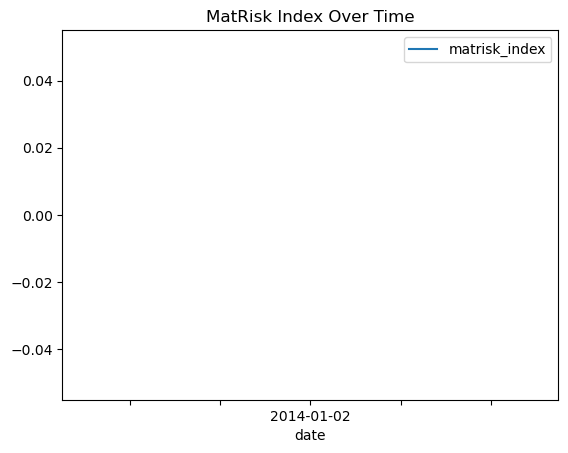

In [11]:
final.plot(x="date", y="matrisk_index", kind="line", title="MatRisk Index Over Time")
plt.show()
